# R1-MJ-1(d) — does ancestry add discovery beyond sample size?

**The comment.**

> "This increase in discovery is likely primarily driven by the overall increase in sample sizes of
> these large, pan-ancestry meta-analyses (usually still predominantly European), and have very
> little to do with the mix of ancestries contributing to them. These different impacts can be
> teased out of the data by accounting for proportion of European ancestry and overall sample size,
> which I would encourage you to do. Otherwise, the framing needs to be changed."

Also bears on **R1-mn-16** and **R1-mn-17** ("You seem to be conflating statistical power due to
sample size and possible advantages of more diverse cohorts, which you haven't demonstrated").

**What this adds over the reclassification.** `chapters/06-review-r1/ancestry-mixed-split/` answers
*who contributed* — genuinely single-ancestry non-European studies account for 23% of disease genes
against 8% for pan-ancestry studies. That is descriptive and holds regardless of what is computed
here. It does not answer *why*: a large East Asian biobank might contribute because it is large,
not because it is East Asian. This notebook conditions discovery on sample size and asks whether
European proportion still carries signal.

**Model.** One row per study. Negative binomial (NB2), consistent with the vPS/gPS modelling in
Methods. Standard errors clustered by cohort, because many studies share a biobank or a
publication.

$$\text{novel genes}_i \sim \text{NB}\big(\mu_i, \alpha\big), \qquad
\log \mu_i = \beta_0 + \beta_{\text{EUR}}\,p^{\text{EUR}}_i + \beta_N \log_{10} N^{\text{eff}}_i
+ \beta_{\text{year}}\,\text{year}_i$$

The readout is $\beta_{\text{EUR}}$: the effect of European proportion *after* conditioning on
scale. Negative means lower European proportion buys discovery that sample size does not explain.

**Three design decisions, stated up front.**

1. **Year is included.** "Novel" is defined against everything published earlier, so an identical
   study finds fewer novel genes in 2024 than in 2010. Non-European studies skew late (European
   studies were 76.9% of pre-2018 GWAS but 63.8% of 2018-onwards). Omitting year would bias
   *against* the non-European contribution.
2. **European proportion is bimodal**, not uniform on [0, 1] — most studies sit near 1.0 or near
   0.0. A single linear term may fit badly, so the categorical ancestry class and a B-spline in
   European proportion are both fitted alongside it.
3. **Studies are not independent.** UKB, FinnGen, MVP and BBJ each contribute many studies.
   Standard errors are clustered on cohort (project for consortium releases, PubMed ID otherwise).

**Sample.** Studies with at least one prioritised gene in a qualifying credible set. Studies with
no credible set contribute no discovery and would be a mass of structural zeros.

## Setup

In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import patsy
import pyarrow.parquet as pq
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

MAX_YEAR = 2024
SUFFIX = "-r1"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## 1. Per-study covariates

Read straight from the release study index with pyarrow — only flat columns are needed, so no Spark
session is required.

`effectiveSampleSize` follows `RescaledStatistics.compute_effective_sample_size` in
`src/manuscript_methods/rescaled_beta.py`: `prev * (1 - prev) * nSamples` for binary traits, where
`prev = nCases / nSamples`, and plain `nSamples` for quantitative traits. Note that definition omits
the conventional factor of 4; since the model uses `log10`, a constant factor is absorbed into the
intercept and changes nothing.

In [3]:
study_columns = [
    "studyId",
    "projectId",
    "studyType",
    "pubmedId",
    "publicationDate",
    "nCases",
    "nControls",
    "nSamples",
]
studies = pq.read_table(path_to_release_folder + "output/study", columns=study_columns).to_pandas()

# FinnGen R12 carries no publication date in the release; pinned to the R12 release date, as
# everywhere else in this analysis. This matters here because novelty is defined by date.
studies.loc[studies["projectId"] == "FINNGEN_R12", "publicationDate"] = "2024-11-04"
studies["publicationDate"] = pd.to_datetime(studies["publicationDate"], errors="coerce")
studies["year"] = studies["publicationDate"].dt.year

studies = studies[studies["studyType"] == "gwas"].copy()
print(f"GWAS studies in release: {len(studies):,}")

GWAS studies in release: 100,526


In [4]:
def effective_sample_size(df: pd.DataFrame) -> pd.Series:
    """Effective sample size per study, matching the pipeline definition.

    Binary traits use `prev * (1 - prev) * nSamples`; quantitative traits use `nSamples`.

    Args:
        df: study-level table with `nCases`, `nControls` and `nSamples`.

    Returns:
        pandas.Series: effective sample size, NaN where it cannot be computed.
    """
    n = df["nSamples"].astype("float64")
    cases = df["nCases"].astype("float64")
    controls = df["nControls"].astype("float64")
    is_binary = cases.notna() & controls.notna() & (cases > 0) & (controls > 0)
    prevalence = (cases / n).where(is_binary)
    return np.where(is_binary, prevalence * (1 - prevalence) * n, n)


studies["isBinary"] = (
    studies["nCases"].notna() & studies["nControls"].notna() & (studies["nCases"] > 0) & (studies["nControls"] > 0)
)
studies["effectiveSampleSize"] = effective_sample_size(studies)

# Cluster unit: consortium releases cluster on the project, everything else on the publication.
studies["cluster"] = np.where(
    studies["projectId"].ne("GCST"),
    studies["projectId"],
    studies["pubmedId"].fillna(studies["studyId"]),
)

ancestry = pd.read_csv(
    path_to_intermediate_data_folder + f"study_ancestry_classification{SUFFIX}.csv",
    usecols=["studyId", "nfeFraction", "ancestryClass", "predominantAncestry"],
)
studies = studies.merge(ancestry, on="studyId", how="inner")
print(f"studies with an ancestry label: {len(studies):,}")
studies[["nfeFraction", "effectiveSampleSize", "year"]].describe()

studies with an ancestry label: 100,526


,nfeFraction,effectiveSampleSize,year
count,100526.000000,9.994100e+04,100526.000000
mean,0.719130,2.575372e+04,2021.664296
std,0.422262,8.177951e+04,2.793124
min,0.000000,0.000000e+00,2005.000000
25%,0.333333,9.990000e+02,2021.000000
50%,1.000000,5.470684e+03,2022.000000
75%,1.000000,1.662200e+04,2024.000000
max,1.000000,3.382012e+06,2025.000000


### European proportion really is bimodal

Worth seeing before fitting a linear term in it.

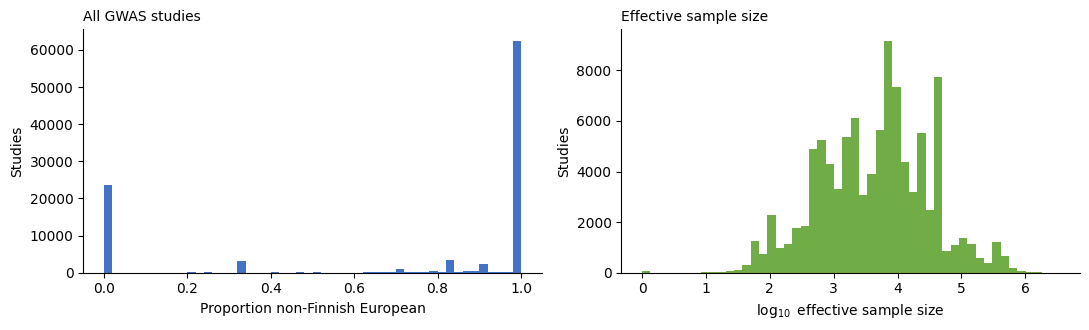

ancestryClass
EUR        65253
non-EUR    23548
mixed      11725


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(studies["nfeFraction"], bins=50, color="#4472C4")
axes[0].set_xlabel("Proportion non-Finnish European")
axes[0].set_ylabel("Studies")
axes[0].set_title("All GWAS studies", loc="left", fontsize=10)
axes[1].hist(np.log10(studies["effectiveSampleSize"].clip(lower=1)), bins=50, color="#70AD47")
axes[1].set_xlabel(r"$\log_{10}$ effective sample size")
axes[1].set_ylabel("Studies")
axes[1].set_title("Effective sample size", loc="left", fontsize=10)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

print(studies["ancestryClass"].value_counts().to_string())

## 2. Outcome — novel genes per study

A gene is credited to the study (or studies) that reported it **earliest by publication date**.
Date resolution rather than year resolution keeps ties rare; where studies do share the earliest
date, all of them are credited, and the number of genes affected is reported below.

Two sensitivity outcomes are built alongside: total distinct genes prioritised by the study
(ignoring novelty) and the number of qualifying credible sets.

In [6]:
def build_study_table(l2g_csv: str, label: str) -> pd.DataFrame:
    """Assemble the per-study modelling table for one trait domain.

    Args:
        l2g_csv: row-level gene-per-credible-set table (`l2g_diseases_full-r1.csv` or the
            measurement equivalent).
        label: trait domain name, stored in the `domain` column.

    Returns:
        pandas.DataFrame: one row per study with outcomes and covariates.
    """
    rows = pd.read_csv(
        path_to_intermediate_data_folder + l2g_csv,
        usecols=["studyId", "studyLocusId", "geneId"],
    )
    rows = rows.merge(studies[["studyId", "publicationDate", "year"]], on="studyId", how="inner")
    rows = rows[rows["year"].notna() & (rows["year"] <= MAX_YEAR)]

    # Earliest publication date per gene; every study reporting on that date is credited.
    first_date = rows.groupby("geneId")["publicationDate"].transform("min")
    rows["is_novel"] = rows["publicationDate"].eq(first_date)

    tied = rows[rows["is_novel"]].groupby("geneId")["studyId"].nunique().pipe(lambda s: (s > 1).sum())
    print(f"[{label}] genes whose earliest publication date is shared by >1 study: {tied:,}")

    per_study = rows.groupby("studyId").agg(
        n_genes=("geneId", "nunique"),
        n_cs=("studyLocusId", "nunique"),
    )
    novel = rows[rows["is_novel"]].groupby("studyId")["geneId"].nunique().rename("novel_genes")
    per_study = per_study.join(novel).fillna({"novel_genes": 0})
    per_study["novel_genes"] = per_study["novel_genes"].astype(int)

    out = per_study.reset_index().merge(studies, on="studyId", how="inner")
    out["domain"] = label
    return out


def prepare_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows the model cannot use and add derived regressors.

    Args:
        df: per-study table from `build_study_table`.

    Returns:
        pandas.DataFrame: model-ready frame with `log10N` and centred `year_c`.
    """
    before = len(df)
    out = df[df["effectiveSampleSize"].notna() & (df["effectiveSampleSize"] > 0) & df["year"].notna()].copy()
    print(f"  dropped {before - len(out):,} of {before:,} studies with missing/zero effective N or year")
    out["log10N"] = np.log10(out["effectiveSampleSize"])
    out["year_c"] = out["year"] - 2015
    out["ancestryClass"] = pd.Categorical(out["ancestryClass"], categories=["EUR", "non-EUR", "mixed"])
    return out


disease = prepare_model_frame(build_study_table(f"l2g_diseases_full{SUFFIX}.csv", "disease"))
measurement = prepare_model_frame(build_study_table(f"l2g_measurements_full{SUFFIX}.csv", "measurement"))

print()
print(f"disease studies modelled:     {len(disease):,}  ({disease['cluster'].nunique():,} clusters)")
print(f"measurement studies modelled: {len(measurement):,}  ({measurement['cluster'].nunique():,} clusters)")
disease[["novel_genes", "n_genes", "n_cs", "log10N", "nfeFraction", "year"]].describe()

[disease] genes whose earliest publication date is shared by >1 study: 1,385
  dropped 0 of 5,349 studies with missing/zero effective N or year


[measurement] genes whose earliest publication date is shared by >1 study: 4,169
  dropped 0 of 21,491 studies with missing/zero effective N or year

disease studies modelled:     5,349  (1,525 clusters)
measurement studies modelled: 21,491  (1,604 clusters)


,novel_genes,n_genes,n_cs,log10N,nfeFraction,year
count,5349.000000,5349.000000,5349.000000,5349.000000,5349.000000,5349.000000
mean,1.903533,11.494111,12.316882,3.805337,0.641359,2021.004300
std,6.369955,28.227079,31.174941,0.672280,0.436290,4.035716
min,0.000000,1.000000,1.000000,1.813964,0.000000,2006.000000
25%,0.000000,1.000000,1.000000,3.321022,0.000000,2019.000000
50%,0.000000,3.000000,3.000000,3.826906,0.893565,2023.000000
75%,1.000000,10.000000,10.000000,4.301214,1.000000,2024.000000
max,161.000000,671.000000,656.000000,5.696994,1.000000,2024.000000


In [7]:
# Outcome is heavily over-dispersed, which is why negative binomial rather than Poisson.
for name, df in [("disease", disease), ("measurement", measurement)]:
    m, v = df["novel_genes"].mean(), df["novel_genes"].var()
    zeros = 100 * (df["novel_genes"] == 0).mean()
    print(f"{name:>12}: mean {m:6.2f}  variance {v:9.2f}  variance/mean {v / m:6.2f}  zeros {zeros:4.1f}%")

     disease: mean   1.90  variance     40.58  variance/mean  21.32  zeros 53.5%
 measurement: mean   1.15  variance     75.02  variance/mean  65.37  zeros 82.1%


## 3. Negative binomial fits

Four specifications per domain:

| | Formula |
| - | ------- |
| **M1** | `novel_genes ~ nfeFraction + log10N` — the comment's literal request |
| **M2** | `+ year_c` — the preregistered primary model; year is a confounder, see the header |
| **M3** | categorical `ancestryClass` in place of the continuous term |
| **M4** | B-spline in European proportion, since it is bimodal. Degrees of freedom are stepped down until the basis is full rank — the point masses at 0 and 1 collapse quantile knots |

All fitted with NB2 and cluster-robust standard errors.

In [8]:
BASE_FORMULAS = {
    "M1: EUR + N": "novel_genes ~ nfeFraction + log10N",
    "M2: + year": "novel_genes ~ nfeFraction + log10N + year_c",
    "M3: ancestry class": "novel_genes ~ C(ancestryClass, Treatment('EUR')) + log10N + year_c",
}


def spline_formula(df: pd.DataFrame, max_df: int = 4) -> tuple[str, int]:
    """Highest-resolution B-spline in European proportion that stays full rank.

    European proportion has large point masses at 0 and 1 — 70% of measurement studies are exactly
    1.0 — so quantile-placed knots collapse onto each other and the basis becomes rank deficient.
    Degrees of freedom are therefore stepped down until the design matrix has full rank.

    Args:
        df: model-ready per-study frame.
        max_df: largest number of spline degrees of freedom to attempt.

    Returns:
        tuple: the formula, and the degrees of freedom it used.
    """
    for spline_df in range(max_df, 1, -1):
        formula = f"novel_genes ~ bs(nfeFraction, df={spline_df}) + log10N + year_c"
        _, design = patsy.dmatrices(formula, df, return_type="dataframe")
        if np.linalg.matrix_rank(design.to_numpy()) == design.shape[1]:
            return formula, spline_df
    raise RuntimeError("no full-rank spline basis found")


FORMULAS = {}
for domain, df in [("disease", disease), ("measurement", measurement)]:
    formulas = dict(BASE_FORMULAS)
    formula, spline_df = spline_formula(df)
    formulas[f"M4: spline in EUR (df={spline_df})"] = formula
    FORMULAS[domain] = formulas
    print(f"{domain}: spline uses df={spline_df}")


def estimate_alpha(df: pd.DataFrame, formula: str) -> float:
    """Estimate the NB2 dispersion by the Cameron-Trivedi auxiliary regression.

    Fitting NB2 by direct maximum likelihood overflows on this data, so dispersion is estimated
    once from a Poisson fit and then held fixed. With `mu` from Poisson, NB2 implies
    `((y - mu)^2 - y) / mu = alpha * mu`, so alpha is the slope of a no-intercept OLS.

    Args:
        df: model-ready per-study frame.
        formula: patsy formula.

    Returns:
        float: estimated dispersion, floored just above zero.
    """
    poisson = smf.glm(formula, data=df, family=sm.families.Poisson()).fit()
    mu = poisson.mu
    y = np.asarray(poisson.model.endog, dtype="float64")
    aux = ((y - mu) ** 2 - y) / mu
    alpha = sm.OLS(aux, mu).fit().params[0]
    return max(float(alpha), 1e-6)


def fit_nb(df: pd.DataFrame, formula: str, alpha: float):
    """Fit NB2 as a GLM at fixed dispersion, with standard errors clustered on cohort.

    Args:
        df: model-ready per-study frame.
        formula: patsy formula.
        alpha: NB2 dispersion from `estimate_alpha`.

    Returns:
        statsmodels GLM results object.
    """
    model = smf.glm(formula, data=df, family=sm.families.NegativeBinomial(alpha=alpha))
    return model.fit(
        cov_type="cluster",
        cov_kwds={"groups": df["cluster"].astype("category").cat.codes},
    )


def tidy(result, model_name: str, domain: str) -> pd.DataFrame:
    """Coefficient table on the incidence-rate-ratio scale.

    Args:
        result: fitted statsmodels result.
        model_name: label for the specification.
        domain: trait domain.

    Returns:
        pandas.DataFrame: one row per term with IRR and 95% CI.
    """
    ci = result.conf_int()
    out = pd.DataFrame(
        {
            "domain": domain,
            "model": model_name,
            "term": result.params.index,
            "coef": result.params.to_numpy(),
            "se": result.bse.to_numpy(),
            "p": result.pvalues.to_numpy(),
            "IRR": np.exp(result.params.to_numpy()),
            "IRR_lo": np.exp(ci[0].to_numpy()),
            "IRR_hi": np.exp(ci[1].to_numpy()),
        }
    )
    return out[~out["term"].isin(["alpha"])]


# One dispersion per domain, estimated from the primary specification and reused across models so
# their log-likelihoods stay comparable.
ALPHA = {
    domain: estimate_alpha(df, BASE_FORMULAS["M2: + year"])
    for domain, df in [("disease", disease), ("measurement", measurement)]
}
print({k: round(v, 4) for k, v in ALPHA.items()})

fits, tables = {}, []
for domain, df in [("disease", disease), ("measurement", measurement)]:
    for name, formula in FORMULAS[domain].items():
        result = fit_nb(df, formula, ALPHA[domain])
        fits[(domain, name)] = result
        tables.append(tidy(result, name, domain))

coefficients = pd.concat(tables, ignore_index=True)
coefficients[coefficients["term"] != "Intercept"].round(4)

disease: spline uses df=4
measurement: spline uses df=3


{'disease': 3.7178, 'measurement': 3.7896}


,domain,model,term,coef,se,p,IRR,IRR_lo,IRR_hi
1,disease,M1: EUR + N,nfeFraction,0.1047,0.0993,0.2913,1.1104,0.9141,1.3489
2,disease,M1: EUR + N,log10N,0.8072,0.1460,0.0000,2.2416,1.6837,2.9844
4,disease,M2: + year,nfeFraction,-0.5234,0.1347,0.0001,0.5925,0.4550,0.7715
5,disease,M2: + year,log10N,1.2992,0.1466,0.0000,3.6662,2.7508,4.8862
6,disease,M2: + year,year_c,-0.1800,0.0273,0.0000,0.8353,0.7917,0.8812
8,disease,M3: ancestry class,"C(ancestryClass, Treatment('EUR'))[T.non-EUR]",0.5111,0.1263,0.0001,1.6670,1.3016,2.1351
9,disease,M3: ancestry class,"C(ancestryClass, Treatment('EUR'))[T.mixed]",-0.0273,0.0979,0.7805,0.9731,0.8032,1.1789
10,disease,M3: ancestry class,log10N,1.3081,0.1438,0.0000,3.6992,2.7906,4.9036
11,disease,M3: ancestry class,year_c,-0.1768,0.0260,0.0000,0.8379,0.7962,0.8818
13,disease,M4: spline in EUR (df=4),"bs(nfeFraction, df=4)[0]",0.2175,0.9580,0.8204,1.2430,0.1901,8.1264


### The headline coefficient

`nfeFraction` runs from 0 to 1, so its IRR is the multiplicative change in novel genes going from a
fully non-European study to a fully European one, holding effective sample size and year fixed. The
inverse is the more natural direction to quote: what a fully non-European study gains over a fully
European one of the same size and year.

In [9]:
headline = coefficients[(coefficients["term"] == "nfeFraction")].copy()
headline["IRR_non_eur_vs_eur"] = 1 / headline["IRR"]
headline["CI_non_eur_vs_eur"] = [f"{1 / hi:.2f}-{1 / lo:.2f}" for lo, hi in zip(headline["IRR_lo"], headline["IRR_hi"])]
print("Effect of a fully non-European study vs a fully European one, same effective N and year:")
headline[["domain", "model", "coef", "se", "p", "IRR", "IRR_non_eur_vs_eur", "CI_non_eur_vs_eur"]].round(4)

Effect of a fully non-European study vs a fully European one, same effective N and year:


,domain,model,coef,se,p,IRR,IRR_non_eur_vs_eur,CI_non_eur_vs_eur
1,disease,M1: EUR + N,0.1047,0.0993,0.2913,1.1104,0.9006,0.74-1.09
4,disease,M2: + year,-0.5234,0.1347,0.0001,0.5925,1.6877,1.30-2.20
20,measurement,M1: EUR + N,-0.5735,0.3859,0.1373,0.5636,1.7744,0.83-3.78
23,measurement,M2: + year,-1.2145,0.3069,0.0001,0.2969,3.3686,1.85-6.15


In [10]:
# Primary model, printed in full for the supplementary table.
print(fits[("disease", "M2: + year")].summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            novel_genes   No. Observations:                 5349
Model:                            GLM   Df Residuals:                     5345
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8434.0
Date:                Mon, 10 Aug 2026   Deviance:                       3557.4
Time:                        17:37:09   Pearson chi2:                 1.02e+04
No. Iterations:                    16   Pseudo R-squ. (CS):             0.1599
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -3.2758      0.512     -6.402      

In [11]:
# Ancestry class contrasts (M3), the bimodality-robust reading of the same question.
classes = coefficients[coefficients["term"].str.contains("ancestryClass", regex=False)].copy()
classes["term"] = classes["term"].str.replace(r".*\[T\.(.*)\]", r"\1", regex=True)
classes[["domain", "model", "term", "coef", "se", "p", "IRR", "IRR_lo", "IRR_hi"]].round(4)

,domain,model,term,coef,se,p,IRR,IRR_lo,IRR_hi
8,disease,M3: ancestry class,non-EUR,0.5111,0.1263,0.0001,1.6670,1.3016,2.1351
9,disease,M3: ancestry class,mixed,-0.0273,0.0979,0.7805,0.9731,0.8032,1.1789
27,measurement,M3: ancestry class,non-EUR,1.3465,0.3361,0.0001,3.8441,1.9893,7.4280
28,measurement,M3: ancestry class,mixed,-0.4703,0.3618,0.1937,0.6248,0.3074,1.2699


## 4. Is the sample-size story enough on its own?

Two checks that do not depend on the linear term: how much of the deviance European proportion adds
over a model with scale and year only, and what the raw data look like once sample size is held
roughly fixed.

In [12]:
rows = []
for domain, df in [("disease", disease), ("measurement", measurement)]:
    base = fit_nb(df, "novel_genes ~ log10N + year_c", ALPHA[domain])
    full = fits[(domain, "M2: + year")]
    cls = fits[(domain, "M3: ancestry class")]
    rows.append(
        {
            "domain": domain,
            "llf_scale_only": base.llf,
            "llf_plus_EUR_linear": full.llf,
            "llf_plus_ancestry_class": cls.llf,
            "LR_chi2_linear": 2 * (full.llf - base.llf),
            "LR_chi2_class": 2 * (cls.llf - base.llf),
            "pseudo_R2_scale_only": base.pseudo_rsquared(kind="mcf"),
            "pseudo_R2_plus_EUR": full.pseudo_rsquared(kind="mcf"),
        }
    )
model_comparison = pd.DataFrame(rows)
model_comparison.round(4)

,domain,llf_scale_only,llf_plus_EUR_linear,llf_plus_ancestry_class,LR_chi2_linear,LR_chi2_class,pseudo_R2_scale_only,pseudo_R2_plus_EUR
0,disease,-8459.7712,-8433.9845,-8431.0528,51.5734,57.4368,0.0495,0.0524
1,measurement,-16269.2043,-16023.9845,-15922.0748,490.4396,694.2591,0.2504,0.2617


In [13]:
# Observed novel genes by European-proportion band, within effective sample size quintiles.
def stratified_means(df: pd.DataFrame) -> pd.DataFrame:
    """Mean novel genes by EUR band within effective sample size quintile.

    Args:
        df: model-ready per-study frame.

    Returns:
        pandas.DataFrame: means indexed by sample size quintile and EUR band.
    """
    d = df.copy()
    d["N_quintile"] = pd.qcut(d["log10N"], 5, labels=[f"Q{i}" for i in range(1, 6)])
    d["EUR_band"] = pd.cut(d["nfeFraction"], [-0.01, 0.1, 0.9, 1.01], labels=["<10% EUR", "10-90% EUR", ">90% EUR"])
    return d.pivot_table(index="N_quintile", columns="EUR_band", values="novel_genes", aggfunc="mean", observed=False)


for domain, df in [("disease", disease), ("measurement", measurement)]:
    print(f"=== {domain}: mean novel genes per study ===")
    print(stratified_means(df).round(2).to_string())
    print()

=== disease: mean novel genes per study ===
EUR_band    <10% EUR  10-90% EUR  >90% EUR
N_quintile                                
Q1              0.95        0.60      1.04
Q2              0.60        0.55      1.12
Q3              0.84        0.66      1.58
Q4              1.64        1.24      2.17
Q5              8.07        3.79      4.42

=== measurement: mean novel genes per study ===
EUR_band    <10% EUR  10-90% EUR  >90% EUR
N_quintile                                
Q1              0.27        0.29      0.24
Q2              0.12        0.13      0.13
Q3              0.70        0.08      0.16
Q4              0.51        0.09      0.42
Q5              3.44        4.26      7.05



## 5. Sensitivity — other outcomes

The primary outcome is novel genes because that is the quantity the comment disputes. Repeating the
primary specification with total genes and with credible-set count shows whether the reading depends
on the novelty definition.

In [14]:
sensitivity = []
for domain, df in [("disease", disease), ("measurement", measurement)]:
    for outcome in ["novel_genes", "n_genes", "n_cs"]:
        formula = f"{outcome} ~ nfeFraction + log10N + year_c"
        result = fit_nb(df, formula, estimate_alpha(df, formula))
        row = tidy(result, f"outcome = {outcome}", domain)
        sensitivity.append(row[row["term"] == "nfeFraction"])

sensitivity = pd.concat(sensitivity, ignore_index=True)
sensitivity["IRR_non_eur_vs_eur"] = 1 / sensitivity["IRR"]
sensitivity[["domain", "model", "coef", "se", "p", "IRR", "IRR_non_eur_vs_eur"]].round(4)

,domain,model,coef,se,p,IRR,IRR_non_eur_vs_eur
0,disease,outcome = novel_genes,-0.5234,0.1347,0.0001,0.5925,1.6877
1,disease,outcome = n_genes,-0.4118,0.1139,0.0003,0.6624,1.5096
2,disease,outcome = n_cs,-0.4359,0.1020,0.0000,0.6467,1.5463
3,measurement,outcome = novel_genes,-1.2145,0.3069,0.0001,0.2969,3.3686
4,measurement,outcome = n_genes,-0.6655,0.3227,0.0392,0.5140,1.9454
5,measurement,outcome = n_cs,-0.7095,0.3131,0.0234,0.4919,2.0330


## 5b. Robustness

Two attacks a referee would make first.

**Leave-one-cohort-out.** FinnGen is a large block of single-ancestry (Finnish) studies that all
carry the same pinned publication date, and UK Biobank, MVP and Biobank Japan each contribute many
studies. If the result rests on one cohort, it is not a result. Each of the ten largest clusters is
dropped in turn and the primary model refitted.

**Year specification.** The European-proportion coefficient changes sign when year enters, which is
expected — novelty is defined against everything published earlier, and non-European studies skew
late — but it means the result depends on how year is modelled. Fitting year as a factor removes
the linearity assumption entirely.

In [15]:
def leave_one_cohort_out(df: pd.DataFrame, top: int = 10) -> pd.DataFrame:
    """Refit the primary model dropping each of the largest cohorts in turn.

    Args:
        df: model-ready per-study frame.
        top: how many of the largest clusters to drop, one at a time.

    Returns:
        pandas.DataFrame: the European-proportion coefficient for each refit.
    """
    formula = BASE_FORMULAS["M2: + year"]
    rows = []
    for excluded in [None, *df["cluster"].value_counts().head(top).index]:
        sub = df if excluded is None else df[df["cluster"] != excluded]
        result = fit_nb(sub, formula, estimate_alpha(sub, formula))
        ci = result.conf_int()
        rows.append(
            {
                "excluded": "(none)" if excluded is None else excluded,
                "n_studies": len(sub),
                "coef": result.params["nfeFraction"],
                "p": result.pvalues["nfeFraction"],
                "IRR_non_eur_vs_eur": np.exp(-result.params["nfeFraction"]),
                "CI_lo": np.exp(-ci.loc["nfeFraction", 1]),
                "CI_hi": np.exp(-ci.loc["nfeFraction", 0]),
            }
        )
    return pd.DataFrame(rows)


loco = []
for domain, df in [("disease", disease), ("measurement", measurement)]:
    out = leave_one_cohort_out(df)
    out.insert(0, "domain", domain)
    loco.append(out)
    print(f"=== {domain} ===")
    print(out.round(4).to_string(index=False))
    print()

leave_one_out = pd.concat(loco, ignore_index=True)

=== disease ===
 domain    excluded  n_studies    coef      p  IRR_non_eur_vs_eur  CI_lo  CI_hi
disease      (none)       5349 -0.5234 0.0001              1.6877 1.2962 2.1976
disease    39024449       3911 -0.3901 0.0023              1.4772 1.1491 1.8990
disease FINNGEN_R12       4509 -0.3777 0.0546              1.4590 0.9926 2.1444
disease    34737426       5156 -0.4823 0.0008              1.6198 1.2235 2.1444
disease    30104761       5165 -0.5047 0.0003              1.6564 1.2585 2.1801
disease    34594039       5218 -0.5097 0.0002              1.6648 1.2675 2.1867
disease    36777996       5296 -0.5308 0.0001              1.7003 1.3054 2.2147
disease    33959723       5301 -0.5168 0.0002              1.6767 1.2820 2.1930
disease    34662886       5310 -0.5119 0.0002              1.6684 1.2780 2.1782
disease    32514122       5318 -0.5411 0.0000              1.7178 1.3328 2.2141
disease    32404885       5328 -0.5341 0.0001              1.7059 1.3130 2.2163



=== measurement ===
     domain excluded  n_studies    coef      p  IRR_non_eur_vs_eur  CI_lo  CI_hi
measurement   (none)      21491 -1.2145 0.0001              3.3686 1.8459 6.1472
measurement 38811844      19412 -1.2831 0.0001              3.6077 1.8912 6.8818
measurement 33875891      19674 -1.1350 0.0002              3.1111 1.7222 5.6201
measurement 35668104      19970 -1.1247 0.0002              3.0792 1.7175 5.5203
measurement 36635386      20068 -1.1349 0.0002              3.1109 1.7204 5.6254
measurement 37277652      20468 -1.2600 0.0000              3.5253 1.9561 6.3534
measurement 35347128      20748 -1.1798 0.0001              3.2537 1.7830 5.9376
measurement 39271676      20817 -1.1655 0.0001              3.2074 1.7682 5.8180
measurement 34503513      20831 -1.2709 0.0001              3.5642 1.8834 6.7450
measurement 36357675      20876 -1.1684 0.0001              3.2170 1.7663 5.8591
measurement 39024449      20973 -0.9255 0.0078              2.5231 1.2764 4.9876



In [16]:
# Year as a factor rather than a linear trend.
year_specs = []
for domain, df in [("disease", disease), ("measurement", measurement)]:
    for label, formula in [
        ("year linear", "novel_genes ~ nfeFraction + log10N + year_c"),
        ("year factor", "novel_genes ~ nfeFraction + log10N + C(year)"),
        ("no year", "novel_genes ~ nfeFraction + log10N"),
    ]:
        result = fit_nb(df, formula, estimate_alpha(df, formula))
        ci = result.conf_int()
        year_specs.append(
            {
                "domain": domain,
                "spec": label,
                "coef": result.params["nfeFraction"],
                "se": result.bse["nfeFraction"],
                "p": result.pvalues["nfeFraction"],
                "IRR_non_eur_vs_eur": np.exp(-result.params["nfeFraction"]),
                "CI_lo": np.exp(-ci.loc["nfeFraction", 1]),
                "CI_hi": np.exp(-ci.loc["nfeFraction", 0]),
            }
        )

year_specifications = pd.DataFrame(year_specs)
year_specifications.round(4)

,domain,spec,coef,se,p,IRR_non_eur_vs_eur,CI_lo,CI_hi
0,disease,year linear,-0.5234,0.1347,0.0001,1.6877,1.2962,2.1976
1,disease,year factor,-0.6978,0.1732,0.0001,2.0094,1.4310,2.8216
2,disease,no year,0.1064,0.1007,0.2909,0.8991,0.7381,1.0953
3,measurement,year linear,-1.2145,0.3069,0.0001,3.3686,1.8459,6.1472
4,measurement,year factor,-0.9651,0.2407,0.0001,2.6250,1.6377,4.2076
5,measurement,no year,-0.6138,0.4059,0.1305,1.8475,0.8337,4.0937


## 6. Write outputs

In [17]:
outputs = {
    f"regression_coefficients{SUFFIX}.csv": coefficients,
    f"regression_headline{SUFFIX}.csv": headline,
    f"regression_model_comparison{SUFFIX}.csv": model_comparison,
    f"regression_sensitivity{SUFFIX}.csv": sensitivity,
    f"regression_leave_one_cohort_out{SUFFIX}.csv": leave_one_out,
    f"regression_year_specifications{SUFFIX}.csv": year_specifications,
}
for name, table in outputs.items():
    path = path_to_intermediate_data_folder + name
    table.to_csv(path, index=False)
    print(f"wrote {path}  ({len(table):,} rows)")

# Per-study modelling table, so the fit can be reproduced without rebuilding it.
model_frame = pd.concat([disease, measurement], ignore_index=True)
model_frame_path = path_to_intermediate_data_folder + f"regression_study_table{SUFFIX}.csv"
model_frame.to_csv(model_frame_path, index=False)
print(f"wrote {model_frame_path}  ({len(model_frame):,} rows)")

wrote ../../../data/intermediate_files/regression_coefficients-r1.csv  (37 rows)
wrote ../../../data/intermediate_files/regression_headline-r1.csv  (4 rows)
wrote ../../../data/intermediate_files/regression_model_comparison-r1.csv  (2 rows)
wrote ../../../data/intermediate_files/regression_sensitivity-r1.csv  (6 rows)
wrote ../../../data/intermediate_files/regression_leave_one_cohort_out-r1.csv  (22 rows)
wrote ../../../data/intermediate_files/regression_year_specifications-r1.csv  (6 rows)
wrote ../../../data/intermediate_files/regression_study_table-r1.csv  (26,840 rows)


## Interpretation

Fill in against the fitted numbers above.

- **`nfeFraction` IRR < 1, significant** — European proportion still predicts discovery after
  conditioning on effective sample size and year. Lower European proportion buys discovery that
  scale does not explain, and the diversity claim can be restated with support.
- **Null** — discovery is explained by scale and calendar time alone. The comment's reading holds on
  the mechanism. The reclassification result is untouched, since 23% versus 8% is a descriptive
  fact about which studies contributed, so the comment is still answered — just without a
  mechanistic claim attached.
- **IRR > 1** — European proportion predicts *more* discovery at fixed size. Report it; better found
  here than by the referee.

In every case the M3 ancestry-class contrasts and the M4 spline should be read alongside the linear
term, because European proportion is bimodal and a single slope through a two-point distribution is
easy to over-read.